## IMPORT LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

## LOAD DATASET

In [3]:
# Connect to SQLite database
conn = sqlite3.connect(r"C:\Users\Vansh Sharma\Desktop\CHURN PROJECT\customer_churn.db")

# Get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

print("Tables in database:")
print(tables)

# Read each table into a DataFrame
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)

    # Create dataframe variable dynamically
    globals()[f"df_{table_name}"] = df

    print(f"\nData from table: {table_name}")
    print(df.head())

# Close connection
conn.close()

Tables in database:
              name
0      db_customer
1  db_subscription
2       db_support

Data from table: db_customer
   customerid    name country        state  gender                  dob  \
0  0002-ORFBO  keshav   India  Maharashtra    Male  1982-04-12 00:00:00   
1  0003-MKNFE  raghav   India    Karnataka    Male  1995-11-23 00:00:00   
2  0004-TLHLJ  lalita   India        Delhi  Female  1978-02-15 00:00:00   
3  0011-IGKFF   mohan   India     Nagaland    Male  2001-08-30 00:00:00   
4  0013-EXCHZ    mira   India        Delhi  Female  1990-05-05 00:00:00   

  interests pincode  
0    travel    None  
1      None    None  
2     movie    None  
3      None    None  
4     drama    None  

Data from table: db_subscription
   customerid subscription_start_date subscription_type renewal_date  \
0  0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1  0003-MKNFE              2020-08-01              Paid   2024-08-01   
2  0004-TLHLJ              2022-11-20    

In [4]:
print(df_db_customer.columns)
print(df_db_customer[["customerid", "name"]].head())

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')
   customerid    name
0  0002-ORFBO  keshav
1  0003-MKNFE  raghav
2  0004-TLHLJ  lalita
3  0011-IGKFF   mohan
4  0013-EXCHZ    mira


In [5]:
df_db_customer.info() #----> clean table 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


 # Data Cleaning Tasks

- Drop two columns: `interests`, `pincode`
- Find missing values in: `country`
- Change data type of: `dob`
- Correct values in: `gender`
- Check for duplicate records

In [6]:
df_db_customer.head() #----> we have to dlt intrests and pincode column

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


DELET  THE COLUMNS

In [7]:
df_db_customer.drop(columns=["interests","pincode"],inplace=True)

# WE CAN ALSO USE [-2:]

In [8]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [9]:
 
df_db_customer["name"].value_counts(dropna=False)

name
keshav        1
rangadevi     1
rishabh       1
raghvendra    1
vishakha      1
rikim         1
parvati       1
Madhav        1
raju          1
chitra        1
shiva         1
raghav        1
arjun         1
maya          1
madan         1
mina          1
durga         1
mira          1
mohan         1
lalita        1
sudevi        1
Name: count, dtype: int64

YES WE CHANGE THE DTYPE

In [10]:
df_db_customer["dob"] = pd.to_datetime(df_db_customer["dob"])

DONE THE COUNTRY COLUMN  

In [11]:
df_db_customer["country"]= df_db_customer["country"].fillna(method="ffill")

C:\Users\Vansh Sharma\AppData\Local\Temp\ipykernel_6980\1258512067.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_db_customer["country"]= df_db_customer["country"].fillna(method="ffill")


GENDER COLUMN DONE

In [12]:
df_db_customer["gender"] = (
    df_db_customer["gender"]
    .str.lower()
    .replace({
        "men": "male",
        "women": "female"
    })
    .str.capitalize()
)

In [13]:
df_db_customer["gender"].value_counts()

gender
Female    12
Male       9
Name: count, dtype: int64

DATA CLEAN FOR df_db_customer

In [14]:
print("="*50)
print(df_db_customer.info())
print("="*50)
print(df_db_customer.shape)
print("="*50)
print(df_db_customer.duplicated().sum())
print("="*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     object        
 1   name        21 non-null     object        
 2   country     21 non-null     object        
 3   state       21 non-null     object        
 4   gender      21 non-null     object        
 5   dob         21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB
None
(21, 6)
0


## NEXT TABLE df_db_subscription

In [15]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [16]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,None,6.99,335,41


### Change Data Type to `datetime`

- `dob`
- `subscription_start_date`
- `renewal_date`
- `cancellation_date`

In [17]:
date_cols = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

df_db_subscription[date_cols] = df_db_subscription[date_cols].apply(
    pd.to_datetime,
    errors="coerce"
)

In [18]:
# df_db_subscription[df_db_subscription.duplicated()]

## DATA CLEAN TASKS

In [19]:
print("="*50)
print(df_db_subscription.info())
print("="*50)
print(df_db_subscription.shape)
print("="*50)
print(df_db_subscription.duplicated().sum())
print("="*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB
None
(21, 11)
0


In [20]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [21]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


# Data Cleaning Tasks

- Drop column: `col_1`
- Remove duplicate records
- Change data type of: `complaint_date`

we can also use
df_db_support = df_db_support.drop(columns=["col_1","comment"])
 

In [22]:
df_db_support = df_db_support.drop(columns="col_1")
# df_db_support.drop(columns="col_1", inplace=True)

In [23]:
df_db_support = df_db_support.drop(columns="comment")
# df_db_support.drop(columns="", inplace=True)

METHOD IS RIGHT BUT NOT WORK FOR FULL ROW USE SUBSET= WILL WORK ON ALL ROWS

In [24]:
# df_db_support["customerid"].duplicated()
# df_db_support["customerid"].dropna_duplicates(keep="first")
# df_db_support=df_db_support.dropna_duplicates(keep="first")

In [25]:
df_db_support = (
    df_db_support
    .dropna(subset=["customerid"])
    .drop_duplicates(subset="customerid", keep="first")
)

In [26]:
df_db_support["complaint_date"] = pd.to_datetime(
    df_db_support["complaint_date"],
    errors="coerce"
)

In [27]:
print("="*60)
print(df_db_support.info())
print("="*60)
print(df_db_support.shape)
print("="*60)
print(df_db_support.duplicated().sum())
print("="*60)

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      7 non-null      object        
 1   complaint_date  7 non-null      datetime64[ns]
 2   escalations     7 non-null      object        
 3   csat_score      7 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 280.0+ bytes
None
(7, 4)
0


# Customer Churn Flag

- Create a `churn_flag` column.
- If `cancellation_date` is available, mark the customer as **Churn**.
- If `cancellation_date` is missing, mark the customer as **Active**.
- Merge the `churn_flag` with the main dataset.

In [28]:
#NEW COLUMN ADD 1-0
df_db_subscription["CHRUN FLAG"]=np.where(df_db_subscription["cancellation_date"].notna(),True,False)

In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,CHRUN FLAG
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,False
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,True
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,False
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,False
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,True


In [30]:
merged_df = pd.merge(
    df_db_customer,
    df_db_subscription,
    on="customerid",
    how="left"
)

merged_df = pd.merge(
    merged_df,
    df_db_support,
    on="customerid",
    how="left"
)

DF=merged_df
DF

,customerid,name,country,state,gender,dob,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,CHRUN FLAG,complaint_date,escalations,csat_score
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,False,NaT,NaN,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,True,2024-08-28,N,60.0
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,False,NaT,NaN,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,False,NaT,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,True,2024-01-20,Y,20.0
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,False,2025-03-18,N,90.0
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,True,2024-11-01,N,30.0
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,False,NaT,NaN,NaN
8,0015-UOCOJ,maya,India,Kathmandu,Female,1985-07-07,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,False,NaT,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,False,NaT,NaN,NaN



## FEATURE ENGINEERING

In [31]:
DF.shape

(21, 20)

In [32]:
DF.to_csv("AFTER MERGE DATA",index= False)

## CHURN RATE

In [33]:
AVG_FLAG = (DF["CHRUN FLAG"].mean() * 100).round(2)
print("CHURN RATE -->", AVG_FLAG, "%")

CHURN RATE --> 28.57 %


## RETENTION RATE

In [34]:
RETENTION=100-AVG_FLAG
print("RETENTION RATE-->",RETENTION,"%")

RETENTION RATE--> 71.43 %


In [35]:
DF.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'CHRUN FLAG', 'complaint_date', 'escalations', 'csat_score'],
      dtype='object')

In [36]:
ACC_PLAN = (DF.groupby("plan_type")["CHRUN FLAG"].mean() .mul(100).round(2)
            .reset_index(name="Churn Rate (%)"))

print(ACC_PLAN)

  plan_type  Churn Rate (%)
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [37]:
ACC_STATE=(DF.groupby("state")["CHRUN FLAG"].mean().mul(100).round(2)
           .reset_index(name=" Churn Rate by state(%)"))
print(ACC_STATE)

           state   Churn Rate by state(%)
0          Delhi                    25.00
1      Karnataka                   100.00
2      Kathmandu                     0.00
3    Maharashtra                     0.00
4      Meghalaya                    66.67
5       Nagaland                     0.00
6      Rajasthan                     0.00
7      Telangana                    50.00
8  Uttar Pradesh                     0.00


In [38]:
ACC_SUBSCRIPTION=(DF.groupby("subscription_type")["CHRUN FLAG"].mean().mul(100).round(2)
                  .reset_index(name="Churn Rate by subscription_type(%) "))
print(ACC_SUBSCRIPTION)

  subscription_type  Churn Rate by subscription_type(%) 
0           Organic                                 0.00
1              Paid                                16.67
2          Refferal                                83.33


In [39]:
state_analysis = DF.groupby("state").agg({
    "customerid": "count",
     'monthly_charges': "sum",
    "CHRUN FLAG": "mean"
}).reset_index()

state_analysis["CHRUN FLAG"] = (state_analysis["CHRUN FLAG"] * 100).round(2)

print(state_analysis)

           state  customerid  monthly_charges  CHRUN FLAG
0          Delhi           4            52.96       25.00
1      Karnataka           2            20.98      100.00
2      Kathmandu           2            20.98        0.00
3    Maharashtra           3            50.97        0.00
4      Meghalaya           3            42.97       66.67
5       Nagaland           1            22.99        0.00
6      Rajasthan           2            36.98        0.00
7      Telangana           2            30.98       50.00
8  Uttar Pradesh           2           115.98        0.00


In [40]:
Subscription_analysis = DF.groupby("subscription_type").agg({
    "customerid": "count",
    'monthly_charges': "sum",
    "CHRUN FLAG": "mean"
}).reset_index()

Subscription_analysis["CHRUN FLAG"] = (Subscription_analysis["CHRUN FLAG"] * 100).round(2)

print(Subscription_analysis)

  subscription_type  customerid  monthly_charges  CHRUN FLAG
0           Organic           9           145.91        0.00
1              Paid           6           174.94       16.67
2          Refferal           6            74.94       83.33


GROUP BY + AGG FUNCTION + INDEX

In [41]:
NEW=DF.groupby("gender")["CHRUN FLAG"].mean().mul(100).round(0).reset_index(name="ACC TO GENDER")
  
 
print(NEW)

   gender  ACC TO GENDER
0  Female           33.0
1    Male           22.0


In [42]:
ARPU = DF["monthly_charges"].sum() / DF["customerid"].count()  # WE CAN ALSO USE-->nununique()

print("AVG REVENUE PER USER-->", round(ARPU, 2))

AVG REVENUE PER USER--> 18.85


## 📌 Tenure (Days)

**Tenure** is the total number of days a customer stayed with the company.

- **Cancelled Customer:**  
  `Tenure = Cancellation Date − Subscription Start Date`

- **Active Customer:**  
  `Tenure = Today's Date − Subscription Start Date`

**Functions Used:**
- `pd.Timestamp.today()` → Current date.
- `np.where()` → Applies conditional logic.
- `.notna()` → Checks if cancellation date exists.
- `.dt.days` → Returns the number of days.

> **Why it matters:** Tenure is an important feature in churn analysis. Customers with shorter tenure are generally more likely to churn.

In [43]:
today = pd.Timestamp.today()

DF["Tenure_Days"] = np.where(
    DF["cancellation_date"].notna(),                                # USE LIKE 1 0 IF ELSE

    # If customer has churned
    (DF["cancellation_date"] - DF["subscription_start_date"]).dt.days,     #IF TRUE

    # If customer is active
    (today - DF["subscription_start_date"]).dt.days                        # ELSE
)


AVG_TENURE=DF["Tenure_Days"].mean().round(2)  # if we want in percentage use mul(100)
print("AVGTENURE DAYS-->",AVG_TENURE)

print("="*200)
DF.head()

AVGTENURE DAYS--> 1494.43


,customerid,name,country,state,gender,dob,subscription_start_date,subscription_type,renewal_date,plan_type,...,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,CHRUN FLAG,complaint_date,escalations,csat_score,Tenure_Days
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,2021-03-15,Refferal,2025-03-15,Standard,...,NaT,None,13.99,627,12,False,NaT,NaN,NaN,1947.0
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,2020-08-01,Paid,2024-08-01,Premium,...,2024-09-10,Switched to competitor,12.99,1150,91,True,2024-08-28,N,60.0,1501.0
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,2022-11-20,Organic,2025-11-20,Basic,...,NaT,None,6.99,210,34,False,NaT,NaN,NaN,1332.0
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,2019-05-10,Paid,2025-05-10,Premium,...,NaT,None,22.99,1725,8,False,NaT,NaN,NaN,2622.0
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,2023-01-05,Refferal,2024-01-05,Standard,...,2024-02-28,Too expensive,13.99,195,88,True,2024-01-20,Y,20.0,419.0


## 📌 Revenue at Risk

**Revenue at Risk** is the total revenue that may be lost due to churned customers.

```python
revenue_at_risk = DF.loc[
    DF["CHRUN FLAG"] == 1,
    "monthly_charges"
].sum()

print("Revenue at Risk -->", revenue_at_risk)
```

**Explanation:**
- `loc[]` → Filters only churned customers (`CHRUN FLAG = 1`).
- `"monthly_charges"` → Selects the revenue column.
- `.sum()` → Adds the monthly charges of all churned customers.

> **Note:** `.sum()` returns a single number (`int`/`float`), so use `*` for multiplication if needed, not `.mul()`.

In [44]:
revenue_at_risk = DF.loc[DF["CHRUN FLAG"] == 1, "monthly_charges"].sum()
                                                                         # if we want in % we can't use .mul(100) we use *100  
print("Revenue at Risk-->", revenue_at_risk)

Revenue at Risk--> 73.94


In [45]:
DF.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'CHRUN FLAG', 'complaint_date', 'escalations', 'csat_score',
       'Tenure_Days'],
      dtype='object')

## 📌 Average Escalation Rate

**Escalation Rate** is the percentage of customers whose complaints were escalated.

```python
AVG_ESCALATION = (DF["escalations"] == "Y").mean() * 100

print("Average Escalation Rate -->", round(AVG_ESCALATION, 2), "%")
```

**Explanation:**
- `(DF["escalations"] == "Y")` → Returns `True` for escalated cases and `False` otherwise.
- `.mean()` → Calculates the percentage of `True` values.
- `* 100` → Converts the result into a percentage.
- `round(2)` → Rounds the value to 2 decimal places.

In [46]:
AVG_ESCLATION=(DF["escalations"]=="Y").mean()*100
print("AVG OF ESCALATIONS-->",round(AVG_ESCLATION,2),"%")

AVG OF ESCALATIONS--> 19.05 %


# AVG_COMPLAINTS

In [47]:
# AVG_COMPLAINTS=DF["cOMPLAINT_COUNT"].mean() 
# we cant bcz we don't have complt_count named column

DF["escalations"] ISKE ANDR Y OR N THA USKI JGA 1 0 KRDIA TAKI DATA K SATH CALCULATION ACHE SYE HO SKE

In [48]:
DF["escalations"]=np.where(DF["escalations"]=="Y",1,0) # WE USE
# df_db_support["escalations"].value_counts(dropna=False)
# DF["escalations"] = DF["escalations"].map({"Y": 1, "N": 0})

MOST IMP FIND CORELATION

## 📌 Correlation

**Correlation** measures the relationship between two variables. Its value ranges from **-1 to +1**.

```python
COR_DROPNA = DF[["escalations", "CHRUN FLAG"]].dropna()

CORRELATION = COR_DROPNA["escalations"].corr(COR_DROPNA["CHRUN FLAG"])
```

**Functions Used:**
- `dropna()` → Removes missing values.
- `.corr()` → Calculates the correlation coefficient.

**Range:**
- `+1` → Strong positive correlation
- `0` → No correlation
- `-1` → Strong negative correlation

In [49]:
 
CORLTN_esc_CHURN=DF["escalations"].corr(DF["CHRUN FLAG"])
print("CORELATION BTW ESCALATION AND FLAG-->",round(CORLTN_esc_CHURN,2))


CORELATION BTW ESCALATION AND FLAG--> 0.77


In [50]:
DF["churn_score"]

0     12
1     91
2     34
3      8
4     88
5     22
6     79
7      5
8     34
9     41
10    14
11    83
12    19
13    76
14     3
15    58
16    62
17    27
18    99
19     7
20    47
Name: churn_score, dtype: int64

## 📌 Churn Risk Classification
 
# A new column **`Churn_Risk`** is created to classify customers based on their **churn score**.  
Customers are classified into **Low**, **Mid**, or **High** risk based on their **churn score**.

```python
conditions = [
    (DF["churn_score"] < 50),
    (DF["churn_score"] >= 50) & (DF["churn_score"] <= 70),
    (DF["churn_score"] > 70)
]

choices = ["LOW", "MID", "HIGH"]

DF["Churn_Risk"] = np.select(conditions, choices, default="Unknown")
```

**Functions Used:**
- `np.select()` → Assigns values based on multiple conditions.
- `&` → Combines multiple conditions (AND).
- `default` → Assigns a value if no condition matches.

**Risk Levels:**
- **< 50** → Low Risk
- **50–70** → Mid Risk
- **> 70** → High Risk

In [51]:
CONDETIONS=[
(DF["churn_score"]<50),
(DF["churn_score"]>=50) & (DF["churn_score"]<=70),
(DF["churn_score"]>70)
]

CHOICES=["LOW","MID","HIGH"]

DF["Churn_risk"]=np.select(CONDETIONS,CHOICES,default="Unkown")

## VISUALIZATION

In [52]:
dfv=DF.copy()

In [53]:
dfv.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'CHRUN FLAG', 'complaint_date', 'escalations', 'csat_score',
       'Tenure_Days', 'Churn_risk'],
      dtype='object')

In [54]:
dfv.shape

(21, 22)

## 📈 Monthly Charges Trend

This line chart shows the **total monthly charges** collected over time based on the **subscription start date**.

**Functions Used:**
- `dt.to_period("M")` → Groups data by month.
- `groupby()` → Groups records by month.
- `sum()` → Calculates total monthly charges.
- `plt.plot()` → Creates a line chart.
- `plt.grid()` → Improves chart readability.

**Purpose:** Helps analyze how monthly revenue changes over time.

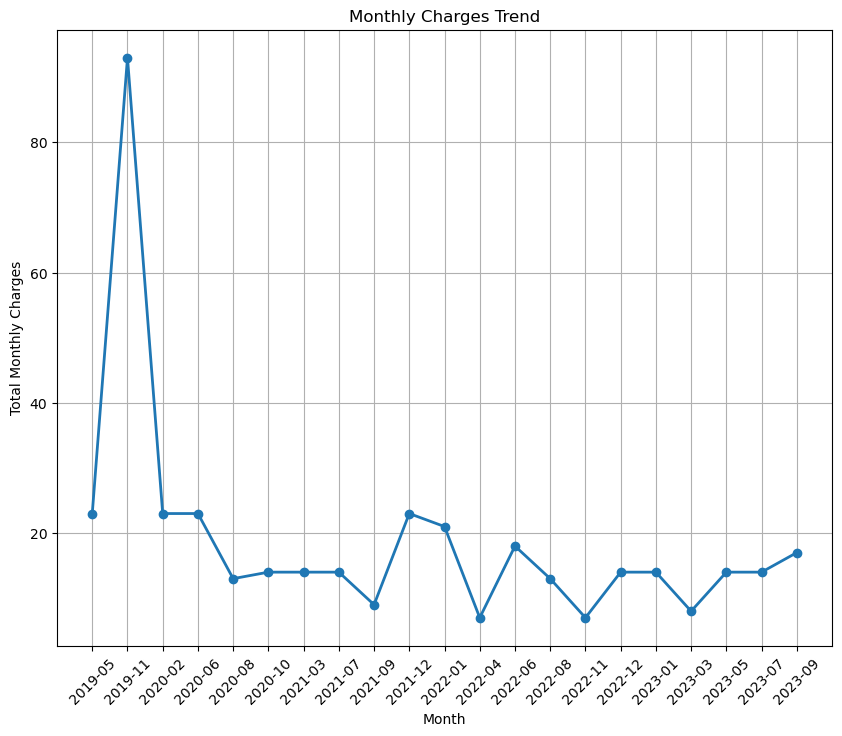

In [55]:
import matplotlib.pyplot as plt

monthly_trend = (
    dfv.groupby(DF["subscription_start_date"].dt.to_period("M"))["monthly_charges"]
      .sum()
)

plt.figure(figsize=(10,8))

plt.plot(
    monthly_trend.index.astype(str),
    monthly_trend.values,
    marker="o",
    linestyle="-",
    linewidth=2
)

plt.title("Monthly Charges Trend")
plt.xlabel("Month")
plt.ylabel("Total Monthly Charges")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# CHURN BY PLAN

## 📊 Churn Rate by Plan Type

Shows the **churn rate (%)** for each plan type.

**Functions Used:**
- `groupby()` → Groups data by plan type.
- `mean()` → Calculates the average churn rate.
- `plt.bar()` → Creates a bar chart.

**Purpose:** Helps identify which plan type has the highest churn.

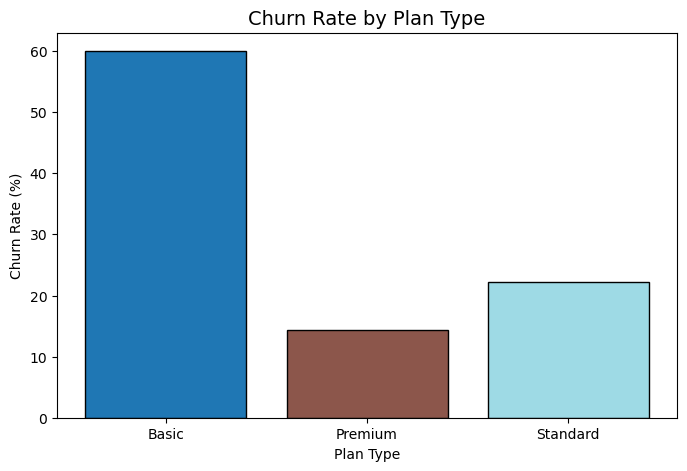

In [56]:
# CHURN_PLAN=dfv.groupby("plan_type")["CHRUN FLAG"].mean()
# print(CHURN_PLAN)

# plt.bar(CHURN_PLAN.index,CHURN_PLAN.values)
# plt.show()


 
CHURN_PLAN = (
    dfv.groupby("plan_type")["CHRUN FLAG"]
       .mean()*100
       
)

colors = plt.cm.tab20(np.linspace(0, 1, len(CHURN_PLAN))) # we use function
plt.figure(figsize=(8,5))

plt.bar(
    CHURN_PLAN.index,
    CHURN_PLAN.values,
    # color=["royalblue", "tomato","seagreen" ],
    color=colors,
    edgecolor="black"
)

plt.title("Churn Rate by Plan Type", fontsize=14)
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")

plt.show()

## 📊 Churn Rate by State

This bar chart shows the **churn rate (%)** for each state.

**Functions Used:**
- `groupby()` → Groups data by state.
- `mean()` → Calculates the average churn rate.
- `* 100` → Converts the churn rate into a percentage.
- `np.linspace()` → Generates evenly spaced values.
- `plt.cm.Set2()` → Applies dynamic colors to the bars.
- `plt.bar()` → Creates a bar chart.
- `plt.title()` → Adds the chart title.
- `plt.xlabel()` / `plt.ylabel()` → Labels the axes.
- `plt.show()` → Displays the chart.

**Purpose:** Helps identify the states with the highest customer churn rate.

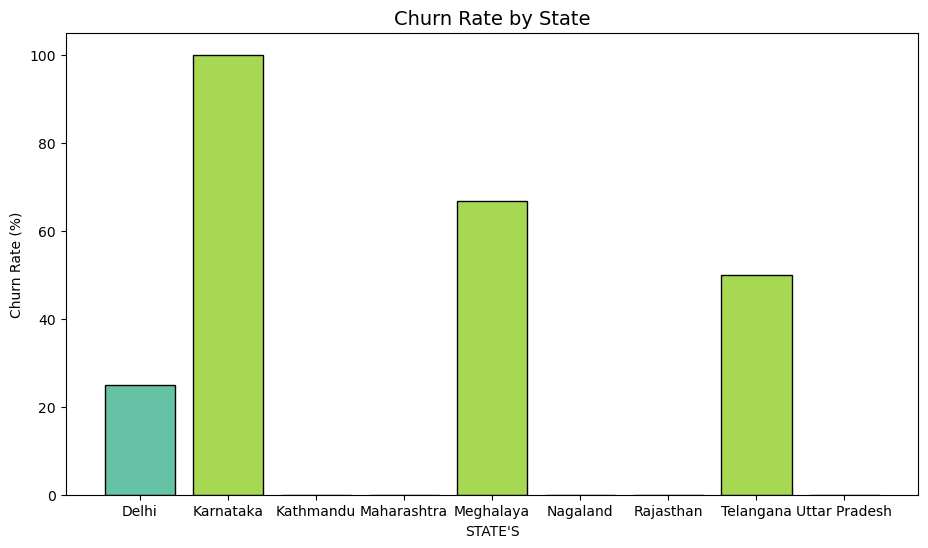

In [57]:
 
CHURN_STATE= (
    dfv.groupby("state")["CHRUN FLAG"]
       .mean()*100
       
)

colors = plt.cm.Set2(np.linspace(0, 1, len(CHURN_PLAN))) # we use function
plt.figure(figsize=(11,6))


plt.bar(
    CHURN_STATE.index,
    CHURN_STATE.values,
    # color=["royalblue", "tomato","seagreen" ],
    color=colors,
    edgecolor="black"
)

plt.title("Churn Rate by State", fontsize=14)
plt.xlabel("STATE'S")
plt.ylabel("Churn Rate (%)")

plt.show()

## 📊 Correlation Heatmap

A **heatmap** is used to visualize the correlation between different features. Correlation can only be calculated on **numeric data**, so categorical columns must be encoded first.

```python
encod = dfv[
    ["plan_type", "churn_score", "contract_type",
     "Churn_risk", "CHRUN FLAG", "escalations"]
].copy()

catg = ["plan_type", "contract_type", "Churn_risk", "CHRUN FLAG"]

for col in catg:
    encod[col] = encod[col].astype("category").cat.codes

sns.heatmap(encod.corr(), annot=True)
```

**Functions Used:**
- `copy()` → Creates a copy of the selected columns.
- `astype("category")` → Converts text values into categorical data.
- `cat.codes` → Automatically assigns numeric codes (e.g., Basic=0, Premium=1, Standard=2).
- `corr()` → Calculates the correlation between numeric columns.
- `sns.heatmap()` → Displays the correlation matrix as a heatmap.
- `annot=True` → Shows the correlation values inside each cell.

**Purpose:** Converts categorical data into numeric values so correlation and the heatmap can be generated correctly.

In [58]:
encod = dfv[[
    "plan_type",
    "churn_score",
    "contract_type",
    "Churn_risk",
    "CHRUN FLAG",
    "escalations"
]].copy()

catg = ["plan_type", "contract_type", "Churn_risk", "CHRUN FLAG"]

for col in catg:
    encod[col] = encod[col].astype("category").cat.codes

In [59]:
dfv[[ "plan_type",
    "churn_score",
    "contract_type",
    "Churn_risk",
    "CHRUN FLAG",
    "escalations"]].head()

,plan_type,churn_score,contract_type,Churn_risk,CHRUN FLAG,escalations
0,Standard,12,Annual,LOW,False,0
1,Premium,91,Annual,HIGH,True,0
2,Basic,34,Monthly,LOW,False,0
3,Premium,8,Annual,LOW,False,0
4,Standard,88,Monthly,HIGH,True,1


In [60]:
encod.head()

,plan_type,churn_score,contract_type,Churn_risk,CHRUN FLAG,escalations
0,2,12,0,1,0,0
1,1,91,0,0,1,0
2,0,34,1,1,0,0
3,1,8,0,1,0,0
4,2,88,1,0,1,1


<Axes: >

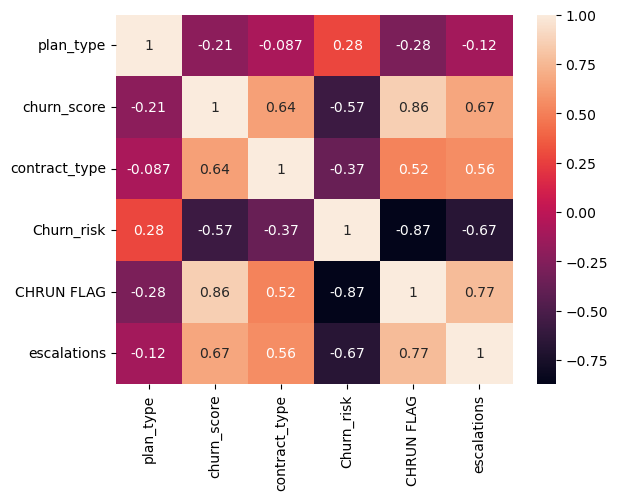

In [61]:
sns.heatmap(encod.corr(),annot=True)

## 📌 Why Use Seaborn Instead of Matplotlib for Heatmaps?

Although a heatmap can be created with **Matplotlib**, **Seaborn** is the preferred choice because it is simpler and provides better visualization.

**Why Seaborn?**
- Less code is required.
- Better default styling and colors.
- Displays correlation values easily using `annot=True`.
- Designed specifically for statistical data visualization.

**Conclusion:** For correlation heatmaps, **Seaborn (`sns.heatmap`) is recommended** because it is more readable, professional, and easier to use than Matplotlib.

In [62]:
# import matplotlib.pyplot as plt

# # Correlation Matrix
# corr_matrix = encod.corr()

# plt.figure(figsize=(8,6))

# plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")

# # Color Bar
# plt.colorbar(label="Correlation")

# # Axis Labels
# plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
# plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# # Add Correlation Values
# for i in range(len(corr_matrix)):
#     for j in range(len(corr_matrix.columns)):
#         plt.text(
#             j, i,
#             f"{corr_matrix.iloc[i, j]:.2f}",
#             ha="center",
#             va="center",
#             color="black",
#             fontsize=9
#         )

# plt.title("Correlation Heatmap")
# plt.tight_layout()

# plt.show()

## 📊 Pair Plot

A **pair plot** visualizes the relationship between multiple features at the same time. It helps identify **patterns, correlations, distributions, and outliers** in the dataset.

```python
sns.pairplot(encod)
```

**Function Used:**
- `sns.pairplot()` → Creates pairwise scatter plots and distributions for all selected features.

**Purpose:** Provides a quick overview of relationships between variables for exploratory data analysis (EDA).

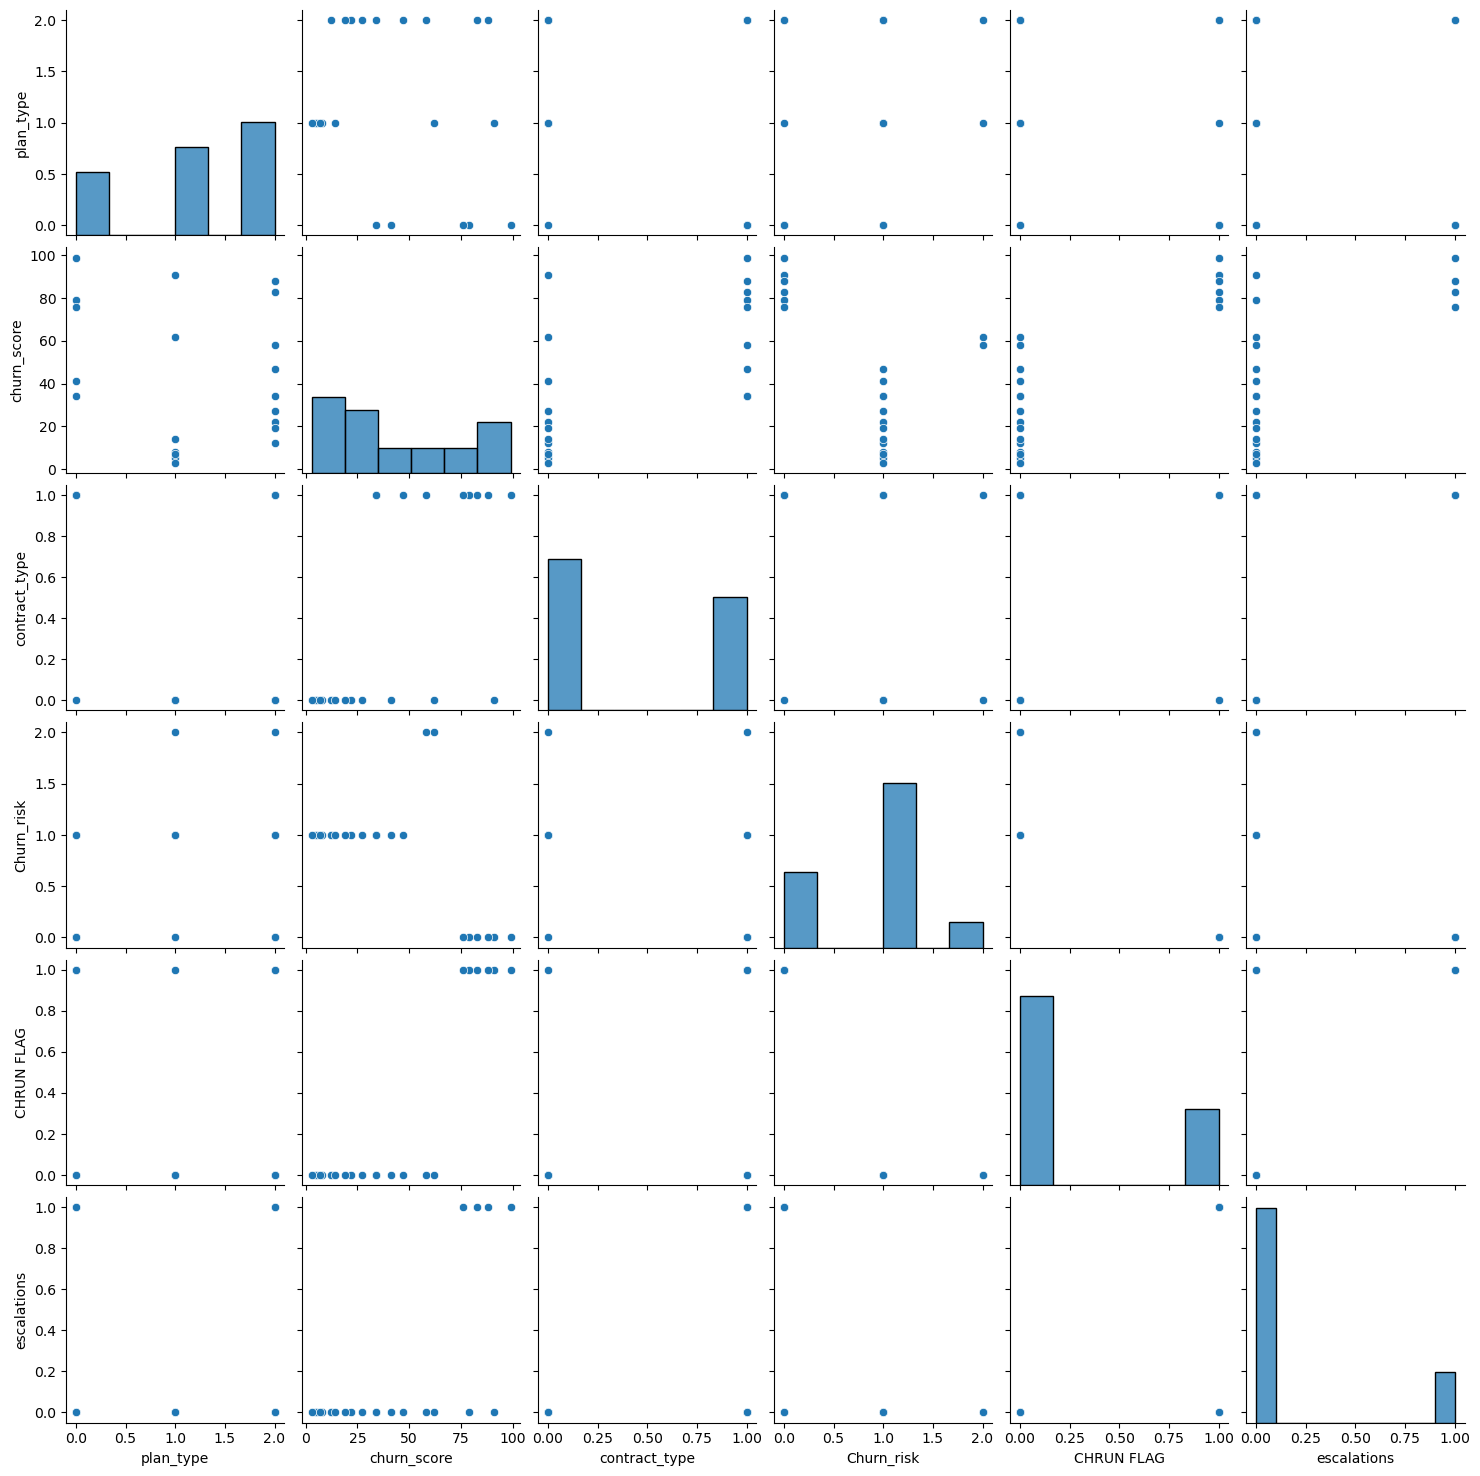

In [63]:
sns.pairplot(encod)

## 📊 Cat Plot (FacetGrid)

A **Cat Plot** is used to compare categorical data across different groups. It can display multiple plots based on a category using **FacetGrid**.

```python
sns.catplot(
    data=dfv,
    x="plan_type",
    y="monthly_charges",
    hue="gender",
    col="churn_risk"
)
```

**Functions Used:**
- `x` → Categorical variable on the X-axis.
- `y` → Numerical variable on the Y-axis.
- `hue` → Compares data using different colors.
- `col` → Creates separate plots for each category.

**Purpose:** Helps compare **monthly charges by plan type**, split by **gender** and **churn risk**, making multi-category analysis easy.

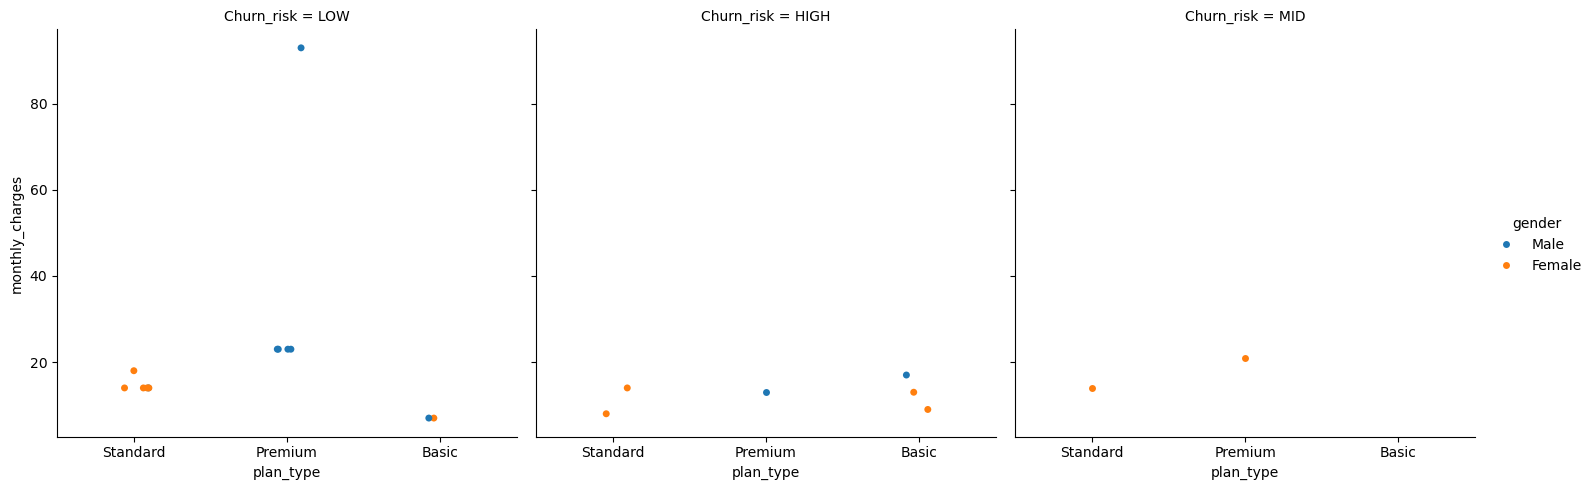

In [68]:
sns.catplot(
    data=dfv,
    x="plan_type",
    y="monthly_charges",
    hue="gender",
    col="Churn_risk"
)

# 📊 Common Charts in Data Analytics

| Chart | Used For |
|--------|----------|
| **Bar Chart** | Compare values across different categories (e.g., Churn by Plan Type, State). |
| **Line Chart** | Show trends or changes over time (e.g., Monthly Charges Trend). |
| **Pie Chart** | Display the proportion or percentage of each category. |
| **Histogram** | Understand the distribution of a numerical variable (e.g., Churn Score). |
| **Box Plot** | Detect outliers and compare data distributions. |
| **Scatter Plot** | Analyze the relationship between two numerical variables. |
| **Heatmap** | Visualize correlations between multiple features. |
| **Pair Plot** | Explore relationships and distributions of multiple variables at once. |
| **Cat Plot (FacetGrid)** | Compare categorical data across different groups. |
| **Count Plot** | Show the frequency (count) of each category. |
| **Violin Plot** | Display data distribution along with density. |
| **KDE Plot** | Visualize the probability density of continuous data. |
| **Area Chart** | Show cumulative trends over time. |
| **Stacked Bar Chart** | Compare categories while showing their composition. |
| **Bubble Chart** | Compare three variables using X, Y, and bubble size. |
| **Hexbin Plot** | Display the density of large scatter plot datasets. |